# Assignment 4: RNNs

In [1]:
# this is used to include model diagram in this file. It is not related to the implementation
from IPython.display import Image

# torch modules
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Dataset from torchvision
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import torch.optim as optim

# We need them for plot (not really asked, but if you would like to plot)
import matplotlib.pyplot as plt
import numpy as np

First and for most we load the MNIST dataset and break it doen into mini-batches.

In [2]:
batch_size = 50

# transformations
transform = transforms.Compose([transforms.ToTensor()])

# Load training dataset
trainset = MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

# Load test dataset
testset = MNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 139MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 42.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 70.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.20MB/s]


We are going to implement the following RNN for MNIST classification via various recurrent units.

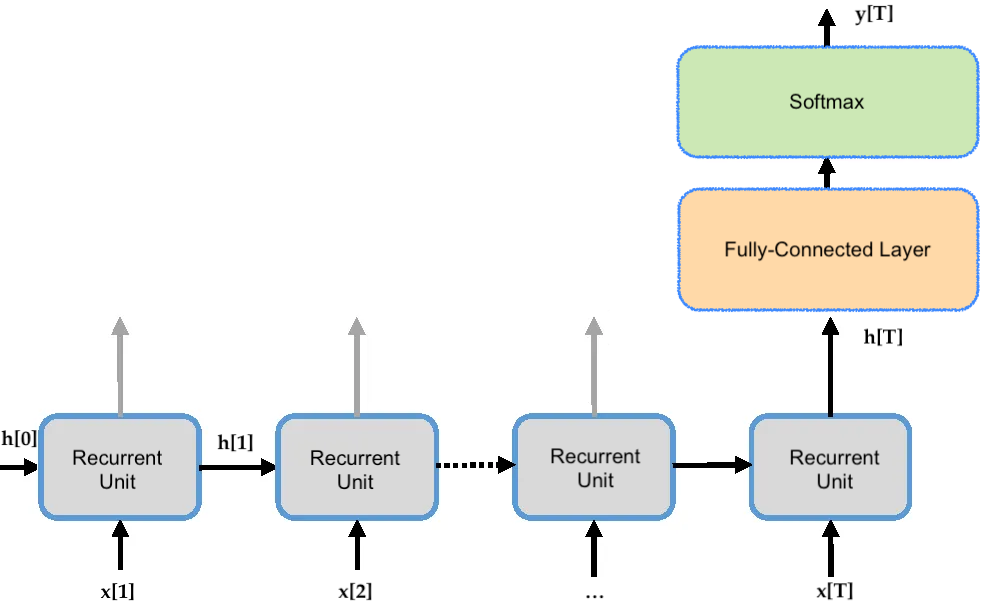

In [ ]:
Image("RNN.png")

## Question 1: Implementing Basic RNN
We implement the RNN via basic Recurrent Unit.

### Building our Model

In [ ]:
class myRNN(nn.Module):
    def __init__(self, batch_size):
        super(myRNN, self).__init__()
        self.h_size = 150
        self.time = 28
        self.x_size = 28
        self.y_size = 10

        # we need batch-size
        # since we should make same-size for initial state
        self.batch_size = batch_size

        self.RecUnit = nn.RNN(input_size=self.x_size, hidden_size=self.h_size, batch_first=True)
        # don't forget setting: batch_first = True

        self.output_layer = nn.Linear(self.h_size, self.y_size)

    def initial_state(self):
         return torch.zeros(1, self.batch_size, self.h_size)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28) => we need (batch_size, seq_len=28, input_size=28)
        x = x.view(self.batch_size, self.time, self.x_size)

        h0 = self.initial_state()

        # RNN returns (all hidden states, last hidden state)
        out_sequence, h_last = self.RecUnit(x, h0)

        # We only care about last time step's output
        last_layer = out_sequence[:, -1, :]  # shape: (batch_size, hidden_size)

        output = self.output_layer(last_layer)  # shape: (batch_size, y_size)
        return output

### Write Accuracy Function

In [3]:
def accuracy(z_out, labels):
    # z_out and labels are both a mini-batch
    pred_labels = torch.argmax(z_out, dim=1)
    correct_pred = (pred_labels == labels).sum().item()
    accuracy = 100.0 * correct_pred / labels.size(0)
    return accuracy

### Implement Training Loop

In [4]:
def train(model, loss_function, num_epochs, trainloader):
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        train_loss = 0.0
        train_accuracy = 0.0

        # training loop
        for i, data in enumerate(trainloader):
            # reset initial states
            model.h_state = model.initial_state()

            # get the inputs
            inputs, labels = data

            # reshape input
            inputs = inputs.view(batch_size, 28, 28)

            # forward pass
            outputs = model(inputs)

            # compute loss
            loss = loss_function(outputs, labels)

            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # update training Loss and accuracy
            train_loss += loss.item()
            train_accuracy += accuracy(outputs, labels)

        print('Epoch:%d | Loss:%.4f | Accuracy:%.2f%%' %
              (epoch + 1, train_loss / len(trainloader), train_accuracy / len(trainloader)))
    return

and now we can train

In [ ]:
# Instantiate model
model = myRNN(batch_size)
loss_function = nn.CrossEntropyLoss()

# complete
train(model, loss_function, 10, trainloader)

Epoch:1 | Loss:0.7360 | Accuracy:75.95%
Epoch:2 | Loss:0.3221 | Accuracy:90.50%
Epoch:3 | Loss:0.2338 | Accuracy:93.44%
Epoch:4 | Loss:0.2024 | Accuracy:94.36%
Epoch:5 | Loss:0.1752 | Accuracy:95.07%
Epoch:6 | Loss:0.1570 | Accuracy:95.61%
Epoch:7 | Loss:0.1505 | Accuracy:95.76%
Epoch:8 | Loss:0.1461 | Accuracy:95.96%
Epoch:9 | Loss:0.1327 | Accuracy:96.32%
Epoch:10 | Loss:0.1294 | Accuracy:96.40%


**Do you think that the same shallow FNN without any recurrence could return
such result?**

No, a shallow FNN  without recurrence likely cannot achieve this level of accuracy on MNIST as simple FNN has only one hidden layer and no convolution layer, it could not capture spatial and temporal relationship as input is sequencial

**How do you think the RNN understands the class of an image?**

RNN processes the image row by row and builds up an internal representation of the digit based on the evolving hidden state. It aims to capture the capture relationships between rows (temporal dependencies in the sequence).
The RNN has advantage over a shallow FNN for tasks with an inherent sequential structure as capture patterns across the rows of the image


### RNN Unit Implementation from scratch
## Not finished

## Question 2: Implementing RNN with Gated Unit
We now replace basic recurrent unit with a GRU.

### Building RNN with GRU

In [5]:
class myGatedRNN(nn.Module):
    def __init__(self, batch_size):
        super(myGatedRNN, self).__init__()
        self.h_size = 128
        self.time = 28
        self.x_size = 28
        self.y_size = 10

        # we need batch-size
        # since we should make same-size for initial state
        self.batch_size = batch_size

        self.RecUnit = nn.GRU(input_size=self.x_size, hidden_size=self.h_size, batch_first=True)
        # don't forget setting: batch_first = True

        self.output_layer = nn.Linear(self.h_size, self.y_size)

    def initial_state(self):
        return torch.zeros(1, self.batch_size, self.h_size).to(next(self.parameters()).device)

    def forward(self, x):
        x = x.view(self.batch_size, self.time, self.x_size)
        h0 = self.initial_state()
        out_seq, h_n = self.RecUnit(x, h0)
        out_last = out_seq[:, -1, :]
        output = self.output_layer(out_last)
        return output

### Train Gated RNN

In [7]:
# Instantiate model
model = myGatedRNN(batch_size)
loss_function = nn.CrossEntropyLoss()

# complete
train(model, loss_function, 10, trainloader)

Epoch:1 | Loss:0.5102 | Accuracy:83.31%
Epoch:2 | Loss:0.1356 | Accuracy:95.91%
Epoch:3 | Loss:0.0865 | Accuracy:97.36%
Epoch:4 | Loss:0.0650 | Accuracy:98.01%
Epoch:5 | Loss:0.0523 | Accuracy:98.39%
Epoch:6 | Loss:0.0435 | Accuracy:98.63%
Epoch:7 | Loss:0.0371 | Accuracy:98.84%
Epoch:8 | Loss:0.0302 | Accuracy:99.07%
Epoch:9 | Loss:0.0279 | Accuracy:99.15%
Epoch:10 | Loss:0.0240 | Accuracy:99.25%


**Compare your result with the previous implementation via basic recurrent unit. Explain your
observation**

Compare to RNN with basic recurrent unit, it has a faster convergence(around 5 epoches compare to 20 epoches), a higher final accuracy(99.25% vs 96.4%) and lower loss(0.024 vs 0.1294),

For Train gated RNN, gating mechanisms (reset and update gates) is introduced and it can control the informantion flow to retain or forget and capture longer-term dependencies without vanishing gradient issues

## Question 3: Implementing RNN with LSTM
We now replace basic recurrent unit with an LSTM.

### Building RNN with LSTM

In [8]:
class myLSTM(nn.Module):
    def __init__(self, batch_size):
        super(myLSTM, self).__init__()
        self.h_size = 128
        self.time = 28
        self.x_size = 28
        self.y_size = 10

        # we need batch-size
        # since we should make same-size for initial state
        self.batch_size = batch_size

        self.RecUnit = nn.LSTM(input_size=self.x_size, hidden_size=self.h_size, batch_first=True)
        # don't forget setting: batch_first = True

        self.output_layer = nn.Linear(self.h_size, self.y_size)
    def initial_state(self):
        h0 = torch.zeros(1, self.batch_size, self.h_size).to(next(self.parameters()).device)
        c0 = torch.zeros(1, self.batch_size, self.h_size).to(next(self.parameters()).device)
        return (h0, c0)

    def forward(self, x):
        x = x.view(self.batch_size, self.time, self.x_size)
        h0, c0 = self.initial_state()
        out_seq, (h_n, c_n) = self.RecUnit(x, (h0, c0))
        out_last = out_seq[:, -1, :]
        output = self.output_layer(out_last)
        return output

### Train LSTM

In [9]:
# Instantiate model
model = myLSTM(batch_size)
loss_function = nn.CrossEntropyLoss()

# complete
train(model, loss_function, 10, trainloader)

Epoch:1 | Loss:0.4771 | Accuracy:84.35%
Epoch:2 | Loss:0.1316 | Accuracy:96.13%
Epoch:3 | Loss:0.0888 | Accuracy:97.35%
Epoch:4 | Loss:0.0706 | Accuracy:97.93%
Epoch:5 | Loss:0.0568 | Accuracy:98.25%
Epoch:6 | Loss:0.0489 | Accuracy:98.56%
Epoch:7 | Loss:0.0405 | Accuracy:98.77%
Epoch:8 | Loss:0.0368 | Accuracy:98.91%
Epoch:9 | Loss:0.0319 | Accuracy:99.02%
Epoch:10 | Loss:0.0273 | Accuracy:99.16%


**Compare your result with the previous two implementations. Explain your observation.**

| Model      | Final Accuracy | Convergence Speed           | Stability       |
|------------|----------------|-----------------------------|-----------------|
| **Basic RNN** | ~96.40%       | Slower (95%+ at Epoch 5)    | Moderate loss   |
| **GRU**       | ~99.25%       | Very fast (95%+ at Epoch 2) | Lowest loss     |
| **LSTM**      | ~99.16%       | Fast (96%+ at Epoch 2)      | Very stable     |

- LSTM and GRU both reach over 99% final accuracy and GRU is slightly better final accuracy and minimized loss earlier, both of them are better than basic RNN
- GRU and LSTM both address the issue of retaining long-term dependencies via gating:

1.   GRU has update + reset gates. it is simple structure and converge faster
2.   LSTM has input, forget, and output gates + cell state.It provides robust learning but takes a bit longer to converge.






